In [8]:
!pip install imbalanced-learn

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


原始数据：样本数 511，特征数 119，正样本比例 0.2603
剔除低方差特征后剩余特征数: 116
剔除高度相关特征后剩余特征数: 90

========== Outer Fold 1/5 ==========
    选中特征数量: 30
    最佳参数: {'clf__class_weight': 'balanced', 'clf__max_depth': 5, 'clf__max_features': 0.3, 'clf__max_samples': 0.8, 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 15, 'clf__n_estimators': 50, 'select__k': 30}
    测试集指标: Acc=0.7961, F1=0.5714, AUC=0.7359, Sen=0.5185, Spe=0.8947

========== Outer Fold 2/5 ==========
    选中特征数量: 20
    最佳参数: {'clf__class_weight': 'balanced', 'clf__max_depth': 8, 'clf__max_features': 0.5, 'clf__max_samples': 0.8, 'clf__min_samples_leaf': 10, 'clf__min_samples_split': 15, 'clf__n_estimators': 20, 'select__k': 20}
    测试集指标: Acc=0.7549, F1=0.4898, AUC=0.7778, Sen=0.4615, Spe=0.8553

========== Outer Fold 3/5 ==========
    选中特征数量: 30
    最佳参数: {'clf__class_weight': 'balanced', 'clf__max_depth': 10, 'clf__max_features': 0.5, 'clf__max_samples': 0.6, 'clf__min_samples_leaf': 10, 'clf__min_samples_split': 15, 'clf__n_estimators': 2

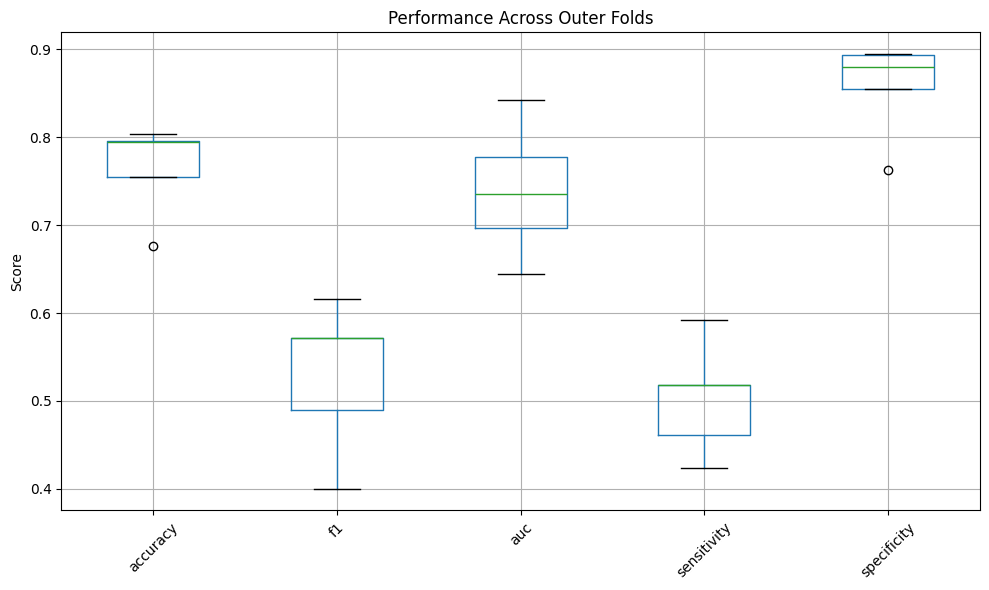


选择第 4 折的模型作为最终模型，其测试集 F1 = 0.6154
最终模型使用的特征数: 30
最终模型超参数: {'memory': None, 'steps': [('smote', SMOTE(random_state=42)), ('select', SelectKBest(k=30, score_func=<function mutual_info_classif at 0x7fd443e3c430>)), ('clf', RandomForestClassifier(class_weight='balanced', max_depth=10, max_features=0.5,
                       max_samples=0.6, min_samples_leaf=5,
                       min_samples_split=15, n_estimators=50, random_state=42))], 'transform_input': None, 'verbose': False, 'smote': SMOTE(random_state=42), 'select': SelectKBest(k=30, score_func=<function mutual_info_classif at 0x7fd443e3c430>), 'clf': RandomForestClassifier(class_weight='balanced', max_depth=10, max_features=0.5,
                       max_samples=0.6, min_samples_leaf=5,
                       min_samples_split=15, n_estimators=50, random_state=42), 'smote__k_neighbors': 5, 'smote__random_state': 42, 'smote__sampling_strategy': 'auto', 'select__k': 30, 'select__score_func': <function mutual_info_classif at 0x7f

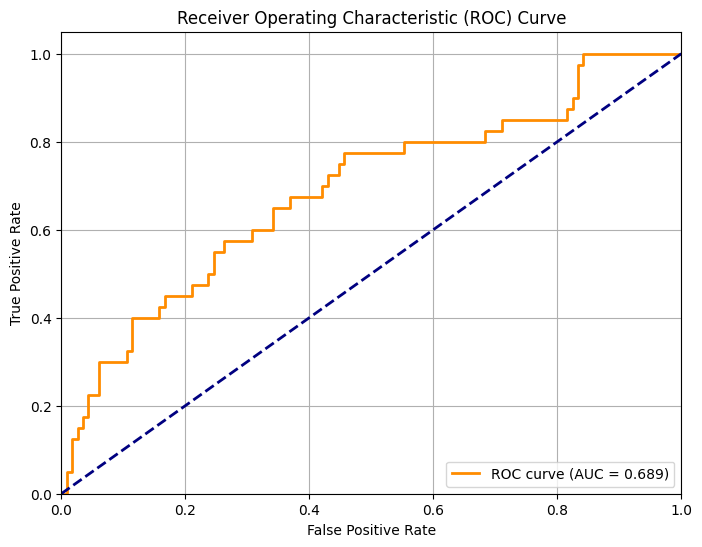


执行 SHAP 分析...
SHAP 图已保存为 rf_shap_bar.png 和 rf_shap_summary.png

绘制学习曲线（对数损失）...


<Figure size 1000x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

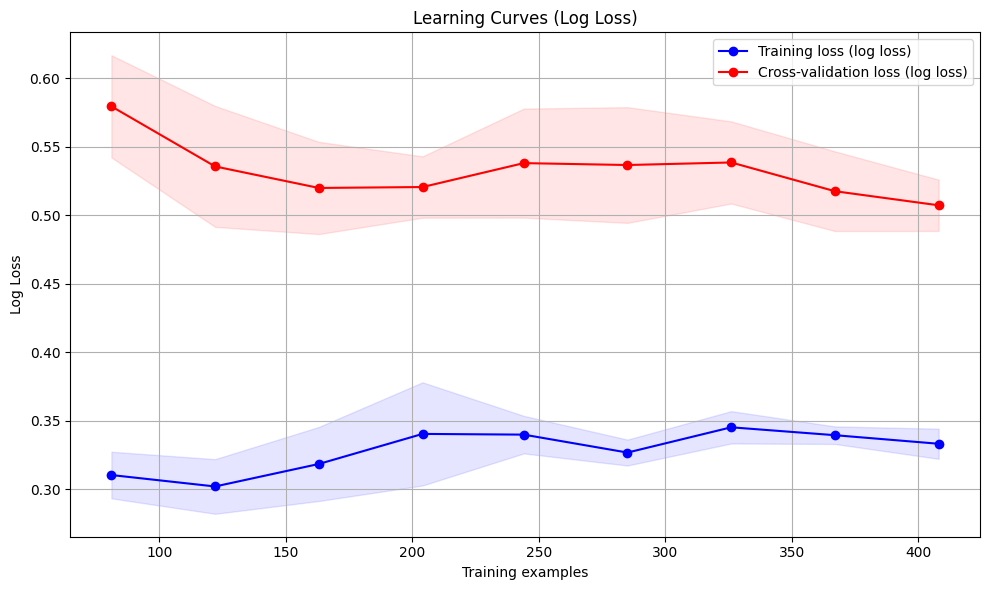

In [1]:
"""
随机森林分类器用于化学物活性预测
包含：数据清洗（低方差/高相关过滤）、互信息特征选择、SMOTE过采样、
嵌套交叉验证、超参数优化、最终模型评估（ROC曲线、SHAP分析、学习曲线）
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif, VarianceThreshold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import shap
import random

# imbalanced-learn 的 Pipeline 和 SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

# ===================== 0. 设置随机种子 =====================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ===================== 1. 加载和预处理数据 =====================
DATA_PATH = '/root/molecular_descriptorsAML9.6-checkpoint.csv'   # 修改为您的文件路径

df = pd.read_csv(DATA_PATH)

# 标签二值化
target_col = 'Activity'
df[target_col] = df[target_col].str.strip().str.lower().map({'active': 1, 'inactive': 0})
df = df.dropna(subset=[target_col])
df[target_col] = df[target_col].astype(int)

# 分离特征和标签
smiles_col = 'SMILES' if 'SMILES' in df.columns else 'smiles'
feat_cols = [col for col in df.columns if col not in [smiles_col, target_col]]
X = df[feat_cols].fillna(0).astype(float)
y = df[target_col]

print(f"原始数据：样本数 {len(X)}，特征数 {X.shape[1]}，正样本比例 {np.mean(y):.4f}")

# ----- 1.1 剔除低方差特征（方差 < 0.01）-----
selector_var = VarianceThreshold(threshold=0.01)
X_var = selector_var.fit_transform(X)
var_mask = selector_var.get_support()
print(f"剔除低方差特征后剩余特征数: {X_var.shape[1]}")

# ----- 1.2 剔除高度相关特征（相关系数 > 0.95）-----
X_var_df = pd.DataFrame(X_var, columns=X.columns[var_mask])
corr_matrix = X_var_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
X_clean = X_var_df.drop(columns=to_drop)
print(f"剔除高度相关特征后剩余特征数: {X_clean.shape[1]}")

# 最终特征矩阵和标签
X_final = X_clean.values
y_final = y.values
feature_names = X_clean.columns.tolist()

# ===================== 2. 嵌套交叉验证参数 =====================
OUTER_K = 5
inner_cv = 5

outer_scores = []           # 存储每折测试集指标
best_models = []            # 存储每折训练好的 Pipeline
selected_feature_masks = [] # 存储每折选择的特征掩码（针对 X_final 的列索引）

skf_outer = StratifiedKFold(n_splits=OUTER_K, shuffle=True, random_state=SEED)

# ===================== 3. 嵌套交叉验证循环 =====================
for fold, (train_idx, test_idx) in enumerate(skf_outer.split(X_final, y_final)):
    print(f"\n========== Outer Fold {fold+1}/{OUTER_K} ==========")

    X_train_fold = X_final[train_idx]
    y_train_fold = y_final[train_idx]
    X_test_fold = X_final[test_idx]
    y_test_fold = y_final[test_idx]

    # ----- 构建 Pipeline：SMOTE -> 互信息特征选择 -> 随机森林 -----
    rf = RandomForestClassifier(random_state=SEED, bootstrap=True)
    selector = SelectKBest(mutual_info_classif, k=20)   # 先设默认 k=20，后面网格搜索会调优
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=SEED)),            # 过采样
        ('select', selector),                           # 特征选择
        ('clf', rf)                                     # 分类器
    ])

    # ----- 超参数网格（针对新 Pipeline）-----
    param_grid = {
        'select__k': [15, 20, 25, 30],                  # 互信息选择的特征数
        'clf__n_estimators': [20, 30, 40, 50],
        'clf__max_depth': [5, 8, 10],
        'clf__min_samples_split': [15, 20],
        'clf__min_samples_leaf': [5, 8, 10],
        'clf__max_features': [0.3, 0.5],
        'clf__class_weight': ['balanced'],
        'clf__max_samples': [0.6, 0.8],
    }

    # ----- 内层交叉验证 + 网格搜索 -----
    grid_search = GridSearchCV(
        pipe,
        param_grid,
        cv=inner_cv,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )
    grid_search.fit(X_train_fold, y_train_fold)

    # ----- 获取最佳模型及信息 -----
    best_pipe = grid_search.best_estimator_
    selected_mask = best_pipe.named_steps['select'].get_support()
    selected_feature_masks.append(selected_mask)
    print(f"    选中特征数量: {np.sum(selected_mask)}")
    print(f"    最佳参数: {grid_search.best_params_}")

    # ----- 测试集评估 -----
    y_pred = best_pipe.predict(X_test_fold)
    y_pred_proba = best_pipe.predict_proba(X_test_fold)[:, 1]

    accuracy = accuracy_score(y_test_fold, y_pred)
    f1 = f1_score(y_test_fold, y_pred)
    auc = roc_auc_score(y_test_fold, y_pred_proba)
    tn, fp, fn, tp = confusion_matrix(y_test_fold, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    metrics = {
        'accuracy': accuracy,
        'f1': f1,
        'auc': auc,
        'sensitivity': sensitivity,
        'specificity': specificity
    }
    outer_scores.append(metrics)
    print(f"    测试集指标: Acc={accuracy:.4f}, F1={f1:.4f}, AUC={auc:.4f}, Sen={sensitivity:.4f}, Spe={specificity:.4f}")

    best_models.append(best_pipe)

# ===================== 4. 汇总嵌套交叉验证结果 =====================
print("\n" + "="*50)
print("嵌套交叉验证结果汇总")
print("="*50)

metrics_names = ['accuracy', 'f1', 'auc', 'sensitivity', 'specificity']
for m in metrics_names:
    values = [score[m] for score in outer_scores]
    print(f"{m}: {np.mean(values):.4f} ± {np.std(values):.4f}")

# 保存各折结果
results_df = pd.DataFrame(outer_scores)
results_df.to_csv('rf_nested_cv_results.csv', index=False)
print("\n各折指标已保存至 'rf_nested_cv_results.csv'")

# 绘制性能箱线图
plt.figure(figsize=(10, 6))
results_df.boxplot()
plt.title('Performance Across Outer Folds')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('rf_nested_cv_boxplot.png', dpi=300)
plt.show()

# ===================== 5. 确定最终模型（选择最佳折）=====================
best_idx = np.argmax([score['f1'] for score in outer_scores])
best_fold_model = best_models[best_idx]
print(f"\n选择第 {best_idx+1} 折的模型作为最终模型，其测试集 F1 = {outer_scores[best_idx]['f1']:.4f}")
print(f"最终模型使用的特征数: {np.sum(selected_feature_masks[best_idx])}")
print(f"最终模型超参数: {best_fold_model.get_params()}")

# ===================== 6. 最终模型在独立测试集上的评估 =====================
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final, y_final, test_size=0.3, random_state=SEED, stratify=y_final
)

best_fold_model.fit(X_train_final, y_train_final)
y_pred_final = best_fold_model.predict(X_test_final)
y_pred_proba_final = best_fold_model.predict_proba(X_test_final)[:, 1]

accuracy_final = accuracy_score(y_test_final, y_pred_final)
f1_final = f1_score(y_test_final, y_pred_final)
auc_final = roc_auc_score(y_test_final, y_pred_proba_final)
tn, fp, fn, tp = confusion_matrix(y_test_final, y_pred_final).ravel()
sensitivity_final = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity_final = tn / (tn + fp) if (tn + fp) > 0 else 0.0

print("\n最终模型在独立测试集上的性能:")
print(f"准确率: {accuracy_final:.4f}")
print(f"F1分数: {f1_final:.4f}")
print(f"AUC: {auc_final:.4f}")
print(f"灵敏度: {sensitivity_final:.4f}")
print(f"特异度: {specificity_final:.4f}")

# ===================== 7. ROC 曲线 =====================
fpr, tpr, _ = roc_curve(y_test_final, y_pred_proba_final)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_final:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig('rf_final_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# ===================== 8. SHAP 分析 =====================
print("\n执行 SHAP 分析...")

rf_model = best_fold_model.named_steps['clf']
selector = best_fold_model.named_steps['select']
selected_mask = selector.get_support()

X_train_selected = X_train_final[:, selected_mask]
X_test_selected = X_test_final[:, selected_mask]

explainer = shap.TreeExplainer(rf_model, X_train_selected, model_output='probability')
shap_values = explainer.shap_values(X_test_selected, check_additivity=False)

if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

selected_feature_names = [feature_names[i] for i, flag in enumerate(selected_mask) if flag]

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_to_plot, X_test_selected, feature_names=selected_feature_names, plot_type="bar", show=False, max_display=20)
plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.savefig('rf_shap_bar.png', dpi=300, bbox_inches='tight')
plt.close()

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_to_plot, X_test_selected, feature_names=selected_feature_names, show=False, max_display=20)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.savefig('rf_shap_summary.png', dpi=300, bbox_inches='tight')
plt.close()

print("SHAP 图已保存为 rf_shap_bar.png 和 rf_shap_summary.png")

# ===================== 9. 学习曲线（使用对数损失）=====================
# ===================== 9. 学习曲线（使用对数损失）=====================
print("\n绘制学习曲线（对数损失）...")

train_sizes, train_scores, test_scores = learning_curve(
    best_fold_model, X_final, y_final,
    cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_log_loss'           # 负对数损失
)

# 转换为正对数损失
train_loss_mean = -np.mean(train_scores, axis=1)
train_loss_std = np.std(train_scores, axis=1)
test_loss_mean = -np.mean(test_scores, axis=1)
test_loss_std = np.std(test_scores, axis=1)

# 绘制学习曲线
plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes, train_loss_mean - train_loss_std,
                 train_loss_mean + train_loss_std, alpha=0.1, color="b")
plt.fill_between(train_sizes, test_loss_mean - test_loss_std,
                 test_loss_mean + test_loss_std, alpha=0.1, color="r")
plt.plot(train_sizes, train_loss_mean, 'o-', color="b", 
         label="Training loss (log loss)")
plt.plot(train_sizes, test_loss_mean, 'o-', color="r", 
         label="Cross-validation loss (log loss)")

# 设置坐标轴
plt.xlabel("Training examples")
plt.ylabel("Log Loss")                      # 明确纵轴为损失值
plt.title("Learning Curves (Log Loss)")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.savefig('rf_learning_curve_loss.png', dpi=300, bbox_inches='tight')
plt.show()